<a href="https://colab.research.google.com/github/sophiamg0228/Integracion-de-datos-y-prospectiva/blob/main/Fuzyy_logic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de estudio**

Se queire implementar un sistems basado en los conceptos de la logica borrosa para la gestion de pacientes en los diferentes puntos de atencion que posee una EPS en Antioquia. Para esta gestion de pacientes, el punto de partida sera la creacion de una matriz de riesgo que permita modelar la variable de atenciones y la variable de severidad como variables linguisticas (numeros-clusters, cualidades, pertenencia).
Esta matriz nos permitira caracterizar los pacientes en diferentes niveles de riesgo, integrando informacion cualitativa.


0. se procede con la carga de datos

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

1. se construye el metodo de clusterizacion

In [30]:
def clusterizacion(Xi):

  #Proceso de Clusterización
  XC=np.random.choice(Xi,size=5)
  XC=np.sort(XC) #Semillas de la Clusterización (Improbable, Posible, Ocasional, Probable, Frecuente)
  nc=np.zeros((len(Xi),1)) #Aquí clasifico los datos en cada una de las semillas

  for k in range(len(Xi)):
    d=np.abs(XC-Xi[k])  #Distancia de un dato a cada semilla
    nc[k]=np.argmin(d)
    nc2=np.int32(nc[k]) #Número de pertenencia al cluster en enteros
    XC[nc2,]=(XC[nc2,]+Xi[k])/2  #Actualizamos la semilla a la que pertenece cada dato (K-Medoids)

  return XC,nc   #Me retorna clusters y cluster al que pertenece un dato

2. se procede con la clusterizacion de las variables de frecuencia y severidad

In [31]:
np.random.seed(42)
nxl='/content/5. Diabetes Árbol_Int_Mult.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB=XDB.dropna() #Elimina los datos faltantes


Xf=np.array (XDB.iloc[:,9])
Xs=np.array (XDB.iloc[:,10])


#1. Buscamos los Fuzzy sets Xf

XCf,ncf=clusterizacion(Xf) # XCf indica los concentradores de informacion
                            # ncf cluster al que pertenece una persona

lbf=['Raro','Poco Probable','Moderado','Probable','Seguro']

XCs,ncs=clusterizacion(Xs) # XCs indica los concentradores de informacion
                            # ncs cluster al que pertenece una persona
lbs=['Insignificante','Menor','Significativo','Mayor','Severo']

sigmaf=[] #bases para la variable
sigmas=[]

for i in range(5):
  sigmaf.append(np.sqrt((np.sum((XCf-XCf[i,])**2)/4)))
  sigmas.append(np.sqrt((np.sum((XCs-XCs[i,])**2)/4)))

print("Los clusters de frecuecia son:", XCf)
print("Los clusters de severidad son:", XCs)







Los clusters de frecuecia son: [1 3 5 7 9]
Los clusters de severidad son: [122.90832717 217.1107508  348.35432281 422.19155248 471.54508412]


3. Calaculamos la pertencia para un pacienta que ha ido al medico durante el año 4 veces y el costo por atencion promedio ha sido de 250USD

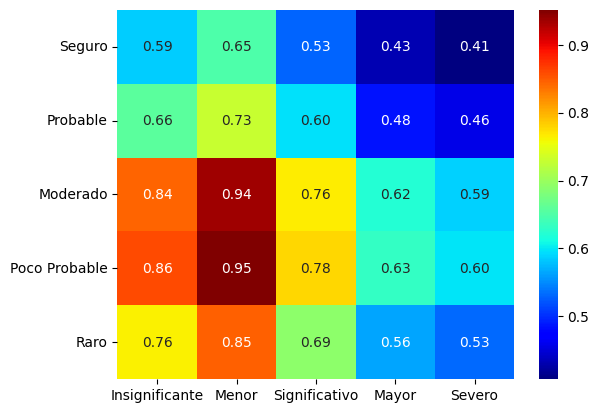

In [42]:
Xfp=4 ; Xsp=250

VPf=np.exp(-0.5*((XCf-Xfp)/sigmaf)**2)
VPs=np.exp(-0.5*((XCs-Xsp)/sigmas)**2)

#COnstruimos la matriz de pertenencia

MVP=np.outer(VPf,VPs)

plt.figure()
sns.heatmap(MVP[::-1], annot= True, fmt='.2f', cmap='jet', xticklabels=lbs,yticklabels=lbf[::-1])
plt.show()
